# What this covers for a team

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/mini-saas-products/portfolio-dashboard/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=mini-saas-products/portfolio-dashboard/demo.ipynb)

A catalog is only useful if somebody arriving with a problem can find the thing
that solves it. Three ways in:

| | question |
|---|---|
| **by job** | *Do you have something for this?* |
| **by role** | *What does this give my data engineer?* |
| **by situation** | *Walk me through what you would use, in order.* |

Sourced from `one-data-platform/homepage/catalog.json`, which is generated from
the tracker. This notebook does not re-parse the tracker: two readers of one
file with their own parsers are two sources of truth wearing a costume, and this
tool used to be the second one.

## The catalog

A snapshot is embedded so this runs anywhere. If you have the repo checked out it
loads the live file instead and tells you which one you got.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List

SNAPSHOT = json.loads(r"""[{"slug":"csv-loader","name":"CSV to PostgreSQL Loader","task":"ingest","task_title":"Move data in","problem":"Loading data into our database is a manual nightmare - copy-paste into SQL, fight with column types, pray nothing breaks.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/csv-loader"},{"slug":"schema-diff","name":"Schema Diff Tool","task":"trust","task_title":"Prove it is right","problem":"Database migrations break things silently - catch schema changes before they hit production.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/schema-diff"},{"slug":"api-warehouse-connector","name":"API to Warehouse Connector","task":"ingest","task_title":"Move data in","problem":"Every Monday, someone on the team downloads CSVs from five different SaaS tools. This replaces that.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/api-warehouse-connector"},{"slug":"data-freshness-monitor","name":"Data Freshness Monitor","task":"observe","task_title":"Know when it breaks","problem":"Dashboards show stale data and nobody notices - this tool catches it first.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/data-freshness-monitor"},{"slug":"pii-detector","name":"PII Detector and Masker","task":"govern","task_title":"Control who sees what","problem":"\"We accidentally share sensitive data in staging\" - scan CSV data for PII and mask it before it leaves production.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/pii-detector"},{"slug":"erd-generator","name":"ERD Generator from SQL","task":"govern","task_title":"Control who sees what","problem":"\"We don't have database diagrams\" - paste your CREATE TABLE statements and get an instant ER diagram.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/erd-generator"},{"slug":"dbt-model-generator","name":"dbt Model Generator","task":"automate","task_title":"Make it run itself","problem":"Writing dbt staging models from scratch is repetitive boilerplate - paste your SQL DDL and get production-ready dbt artifacts instantly.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/dbt-model-generator"},{"slug":"data-lineage-viz","name":"Data Lineage Visualizer","task":"govern","task_title":"Control who sees what","problem":"Paste SQL, see what breaks when you change a table.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/data-lineage-viz"},{"slug":"gx-config-generator","name":"Great Expectations Config Generator","task":"trust","task_title":"Prove it is right","problem":"Setting up data validation is tedious - so most teams skip it until something breaks in prod.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/gx-config-generator"},{"slug":"db-health-dashboard","name":"Database Health Dashboard","task":"observe","task_title":"Know when it breaks","problem":"One screen of database visibility - cache hits, latency, locks, replication lag - scored red/amber/green so problems surface before users notice.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-infra-toolkit/db-health-dashboard"},{"slug":"csv-cleaner","name":"CSV Cleaner","task":"shape","task_title":"Make raw values usable","problem":"Turn a messy CSV export into a tidy, analysis-ready file - with an auditable report of every change.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/csv-cleaner"},{"slug":"json-validator","name":"JSON Schema Validator","task":"trust","task_title":"Prove it is right","problem":"A FastAPI microservice that validates JSON payloads against a schema and returns every error at once - so broken API contracts surface before they corrupt data.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/json-validator"},{"slug":"auto-readme","name":"Auto-README Generator","task":"automate","task_title":"Make it run itself","problem":"Scan any repo into a structured profile and generate a README - by template offline, or with Claude for richer prose. Wire it into GitHub Actions to auto-open a docs PR on every push.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/auto-readme"},{"slug":"cron-monitor","name":"Cron Job Monitor","task":"observe","task_title":"Know when it breaks","problem":"A dead-man's-switch for scheduled jobs - heartbeat in, email out when a job goes silent. So you find out batch jobs failed before your users do.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/cron-monitor"},{"slug":"env-checker","name":"Environment Variable Checker","task":"observe","task_title":"Know when it breaks","problem":"A pre-flight check for environment variables - declare what your app needs, validate it before you ship, and fail the deploy if anything's missing or malformed.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/env-checker"},{"slug":"log-parser","name":"Log Parser and Alerter","task":"observe","task_title":"Know when it breaks","problem":"Stop grepping logs by hand. Parse mixed-format logs into structured records, see the severity breakdown and top errors, and fire alerts when errors spike.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/log-parser"},{"slug":"sql-formatter","name":"SQL Query Formatter","task":"automate","task_title":"Make it run itself","problem":"A FastAPI microservice that turns unreadable SQL into a clean house style - and lints it for danger (DELETE with no WHERE) and style (SELECT , implicit joins).","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/sql-formatter"},{"slug":"md-to-pdf","name":"Markdown to PDF Report","task":"automate","task_title":"Make it run itself","problem":"Write the weekly report in Markdown, get a branded, print-ready PDF - cover header, styled tables, page numbers. No more hand-formatting in Word.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/md-to-pdf"},{"slug":"duplicate-finder","name":"Duplicate File Finder","task":"shape","task_title":"Make raw values usable","problem":"Find byte-identical files hiding under different names - efficiently - and reclaim the space. So a shared drive full of duplicates stops costing you storage.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/duplicate-finder"},{"slug":"standup-bot","name":"Daily Standup Bot","task":"automate","task_title":"Make it run itself","problem":"One place for the team's standup. Everyone submits yesterday / today / blockers; the bot rolls it into a single digest with blockers surfaced first. No more scrolling Slack threads.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/standup-bot"},{"slug":"auto-eda","name":"Auto-EDA Dashboard","task":"explore","task_title":"Find out what is in it","problem":"Drop in a CSV, get the whole first-look in seconds - shape, missingness, dtypes, distributions, correlations, and the quality problems worth a human's attention.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/auto-eda"},{"slug":"kpi-tracker","name":"KPI Tracker","task":"measure","task_title":"Turn it into a number people act on","problem":"Execs ask for the same metrics every Monday - this turns a metric time series into the answer automatically.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/kpi-tracker"},{"slug":"ab-test-calc","name":"A/B Test Calculator","task":"infer","task_title":"Decide what is actually true","problem":"Stop eyeballing significance. Enter your A/B numbers, get a proper two-proportion z-test - p-value, confidence interval, and a clear verdict - plus a sample-size planner.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/ab-test-calc"},{"slug":"survey-analyzer","name":"Survey Results Analyzer","task":"explore","task_title":"Find out what is in it","problem":"Turn a raw survey export into a type-aware summary in seconds - NPS, Likert scores, choice breakdowns, and open-text sentiment.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/survey-analyzer"},{"slug":"customer-segments","name":"Customer Segmentation Tool","task":"explore","task_title":"Find out what is in it","problem":"Find your natural customer groups with KMeans - auto-picks the number of segments, names each one, and shows how distinct they really are.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/customer-segments"},{"slug":"churn-predictor","name":"Churn Predictor","task":"predict","task_title":"Learn from it","problem":"Spot at-risk customers before they leave - ranked risk scores, churn drivers, and an honest model-quality check.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/churn-predictor"},{"slug":"sales-forecast","name":"Sales Forecast Dashboard","task":"measure","task_title":"Turn it into a number people act on","problem":"Get sales forecasts out of someone's spreadsheet - a reproducible forecast with a confidence band and an honest accuracy check.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/sales-forecast"},{"slug":"data-quality-scorecard","name":"Data Quality Scorecard","task":"trust","task_title":"Prove it is right","problem":"Stop guessing how bad your data is - get a 0-100 score, a letter grade, and a ranked list of what to fix first.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/data-quality-scorecard"},{"slug":"funnel-analyzer","name":"Funnel Analyzer","task":"measure","task_title":"Turn it into a number people act on","problem":"See exactly where users drop off - biggest leak called out, step-by-step conversion, and a segment comparison.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/funnel-analyzer"},{"slug":"cohort-analysis","name":"Cohort Analysis Tool","task":"measure","task_title":"Turn it into a number people act on","problem":"\"Retention analysis takes our analyst 2 days\" - turn a raw event log into a cohort retention heatmap in seconds.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-accelerator/cohort-analysis"},{"slug":"pdf-qa-bot","name":"PDF Q&A Bot","task":"understand","task_title":"Get answers out of documents","problem":"\"Nobody reads the 200-page policy manual\" - upload it, ask questions, get cited answers.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/pdf-qa-bot"},{"slug":"meeting-summarizer","name":"Meeting Notes Summarizer","task":"understand","task_title":"Get answers out of documents","problem":"\"Meetings produce no actionable output\" - paste the transcript, get TL;DR + decisions + action items + open questions.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/meeting-summarizer"},{"slug":"contract-extractor","name":"Contract Clause Extractor","task":"understand","task_title":"Get answers out of documents","problem":"Turn a 3-day legal read into a 30-second clause + risk triage.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/contract-extractor"},{"slug":"faq-generator","name":"FAQ Generator from Docs","task":"understand","task_title":"Get answers out of documents","problem":"Stop answering the same question daily - turn your docs into a ready FAQ.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/faq-generator"},{"slug":"semantic-search","name":"Semantic Search Engine","task":"understand","task_title":"Get answers out of documents","problem":"Search by meaning, not just exact words - what Ctrl+F can't do.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/semantic-search"},{"slug":"resume-screener","name":"Resume Screener","task":"understand","task_title":"Get answers out of documents","problem":"Rank a stack of resumes by skills fit - a triage aid, not a hiring decision.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/resume-screener"},{"slug":"competitive-intel","name":"Competitive Intel Summarizer","task":"understand","task_title":"Get answers out of documents","problem":"Turn scattered competitor notes into one comparison matrix + strategic takeaways.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/competitive-intel"},{"slug":"data-dict-gen","name":"Data Dictionary Generator","task":"govern","task_title":"Control who sees what","problem":"Point it at a table, get a documented data dictionary - types, PII flags, descriptions.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/data-dict-gen"},{"slug":"compliance-checker","name":"Compliance Checker","task":"govern","task_title":"Control who sees what","problem":"Run a document against a policy ruleset before the auditor does.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/compliance-checker"},{"slug":"knowledge-base","name":"Knowledge Base Builder","task":"understand","task_title":"Get answers out of documents","problem":"Turn scattered docs into a searchable, cited knowledge base - before the expert leaves.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/document-intelligence/knowledge-base"},{"slug":"email-agent","name":"Email Draft Agent","task":"automate","task_title":"Make it run itself","problem":"\"I spend 2 hours daily on email\" - an agent that drafts replies, checks its own work against the original ask, and revises before handing it back.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/email-agent"},{"slug":"code-review-agent","name":"Code Review Agent","task":"automate","task_title":"Make it run itself","problem":"\"PRs sit unreviewed for days\" - an agent that gives every PR an instant first pass so reviewers focus on logic, not nitpicks.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/code-review-agent"},{"slug":"pipeline-monitor-agent","name":"Data Pipeline Monitor Agent","task":"observe","task_title":"Know when it breaks","problem":"\"We discover pipeline failures from angry users\" - an agent that catches failures, slow runs, row-count drops, and silent staleness before anyone downstream notices.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/pipeline-monitor-agent"},{"slug":"ticket-router","name":"Customer Ticket Router","task":"automate","task_title":"Make it run itself","problem":"\"Tickets go to the wrong team 40% of the time\" - an agent that routes tickets by weighted keyword signal, and escalates to human triage instead of guessing when confidence is low.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/ticket-router"},{"slug":"onboarding-agent","name":"Onboarding Checklist Agent","task":"automate","task_title":"Make it run itself","problem":"\"New hires miss steps, ramp-up takes 3 months\" - a multi-step agent that resolves onboarding step dependencies and flags what's overdue or blocked before it cascades.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/onboarding-agent"},{"slug":"incident-agent","name":"Incident Response Agent","task":"observe","task_title":"Know when it breaks","problem":"Incident playbooks exist but nobody follows them - this agent executes the runbook step-by-step and escalates when a remediation step fails.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/incident-agent"},{"slug":"report-agent","name":"Report Generation Agent","task":"automate","task_title":"Make it run itself","problem":"Monthly reports take 2 days of copy-paste - a team of role-specialized agents turns a table of metrics into a ready-to-send report in seconds.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/report-agent"},{"slug":"slack-qa-agent","name":"Slack Q&A Agent","task":"automate","task_title":"Make it run itself","problem":"People ask the same questions in #general every day - this agent answers them from a knowledge base via RAG, and escalates anything it isn't confident about to a human instead of guessing.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/slack-qa-agent"},{"slug":"model-drift-detector","name":"Model Drift Detector","task":"observe","task_title":"Know when it breaks","problem":"Models degrade silently in production - this watches a live window against the training reference via PSI and alerts before accuracy quietly rots.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/model-drift-detector"},{"slug":"agent-eval-dashboard","name":"Agent Evaluation Dashboard","task":"evaluate","task_title":"Check the AI is any good","problem":"\"We don't know if our agents are actually good.\" Run a fixed eval suite against two agent versions and get pass rate, quality, latency, and per-category regressions - numbers instead of vibes.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ai-agent-workshop/agent-eval-dashboard"},{"slug":"idea-validator","name":"Startup Idea Validator","task":"decide","task_title":"Choose, and be able to defend it","problem":"We build before we validate - this scores an idea across five dimensions, builds a Lean Canvas, and hands you the cheapest experiment to test your riskiest assumption first.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/idea-validator"},{"slug":"feedback-analyzer","name":"User Feedback Analyzer","task":"explore","task_title":"Find out what is in it","problem":"We have 10K reviews and no insights - this turns raw feedback into a sentiment split, ranked complaints, ranked praises, and the one thing to fix first.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/feedback-analyzer"},{"slug":"feature-prioritizer","name":"Feature Prioritization Tool","task":"decide","task_title":"Choose, and be able to defend it","problem":"We argue about priorities without data - RICE turns \"I feel strongly about X\" into a rankable, defensible number.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/feature-prioritizer"},{"slug":"retro-generator","name":"Sprint Retrospective Generator","task":"decide","task_title":"Choose, and be able to defend it","problem":"Retros are unstructured and repetitive - feed in the sprint numbers and get grounded observations and concrete action items in your team's format.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/retro-generator"},{"slug":"okr-tracker","name":"OKR Tracker and Advisor","task":"decide","task_title":"Choose, and be able to defend it","problem":"OKRs get set and forgotten - this tracks progress against pace and flags which key results are behind while there's still time to act.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/okr-tracker"},{"slug":"roadmap-viz","name":"Product Roadmap Visualizer","task":"decide","task_title":"Choose, and be able to defend it","problem":"Roadmaps are PowerPoints that go stale - generate the roadmap from data instead: a Gantt-style timeline, grouped by lane, colored by status, with a \"today\" line.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/roadmap-viz"},{"slug":"user-story-gen","name":"User Story Generator","task":"decide","task_title":"Choose, and be able to defend it","problem":"Writing good user stories takes practice - paste raw feature ideas and get INVEST-scored stories with Given/When/Then acceptance criteria.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/user-story-gen"},{"slug":"accessibility-checker","name":"Accessibility Checker","task":"automate","task_title":"Make it run itself","problem":"We don't test for accessibility until the end - paste HTML and get WCAG-referenced findings, severity levels, and a 0-100 score in seconds.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/accessibility-checker"},{"slug":"privacy-policy-gen","name":"Privacy Policy Generator","task":"govern","task_title":"Control who sees what","problem":"Legal templates cost money and are still generic - answer a short questionnaire and get a GDPR/CCPA-aware policy draft plus a checklist of the compliance work the document can't do for you.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/privacy-policy-gen"},{"slug":"portfolio-dashboard","name":"Full Portfolio Dashboard","task":"measure","task_title":"Turn it into a number people act on","problem":"Showcase all 60 projects in one view - the portfolio's final build is the view of the portfolio itself.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/portfolio-dashboard"},{"slug":"incremental-loader","name":"Incremental / CDC Loader","task":"ingest","task_title":"Move data in","problem":"Full reloads take hours every night - load only what changed with watermark extraction, key upsert, and soft-delete tombstones.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/incremental-loader"},{"slug":"airflow-dag-gen","name":"Airflow DAG Generator","task":"automate","task_title":"Make it run itself","problem":"Writing DAG boilerplate is repetitive - describe the pipeline in ~30 lines of YAML and get a validated, ready-to-deploy Airflow DAG.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/airflow-dag-gen"},{"slug":"parquet-partitioner","name":"CSV/JSON to Parquet Partitioner","task":"ingest","task_title":"Move data in","problem":"Our data lake is a pile of CSVs - convert flat files into hive-partitioned, compressed parquet and prove the query speedup with a stopwatch.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/parquet-partitioner"},{"slug":"data-contract-validator","name":"Data Contract Validator","task":"trust","task_title":"Prove it is right","problem":"Producers break schemas without warning - put a YAML contract in CI so breaking changes block the merge and violating data never lands.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/data-contract-validator"},{"slug":"backfill-planner","name":"Backfill Planner","task":"ingest","task_title":"Move data in","problem":"Backfills are error-prone manual scripts - chunk the date range, persist every status, retry the flaky, quarantine the broken, and resume after a crash without repeating a success.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/backfill-planner"},{"slug":"streaming-aggregator","name":"Streaming Window Aggregator","task":"ingest","task_title":"Move data in","problem":"We can't compute rolling metrics live - event-time windows with watermarks in ~100 lines, with the same semantics Flink and Spark charge a cluster for.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/streaming-aggregator"},{"slug":"dedup-pipeline","name":"Dedup & Survivorship Pipeline","task":"shape","task_title":"Make raw values usable","problem":"Duplicate records everywhere - normalize the variants, cluster by match keys, and merge each cluster into a golden record with field-level survivorship and full provenance.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/dedup-pipeline"},{"slug":"api-paginator","name":"API Pagination Extractor","task":"ingest","task_title":"Move data in","problem":"Paginated API pulls are hand-coded each time - one generic extractor speaks offset, page, cursor, and link-follow, with 429 retry/backoff built in.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/api-paginator"},{"slug":"column-lineage","name":"Column-Level Lineage Parser","task":"govern","task_title":"Control who sees what","problem":"Table-level lineage tells you model B reads model A. It can't tell you that renaming orders.amount will silently break total_revenue three hops away.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/column-lineage"},{"slug":"pipeline-sla-monitor","name":"Pipeline SLA Monitor","task":"observe","task_title":"Know when it breaks","problem":"A pipeline that lands late, runs slow, goes stale, or arrives thin usually breaks a consumer before anyone on the data team notices.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/pipeline-sla-monitor"},{"slug":"feature-factory","name":"Feature Engineering Pipeline","task":"predict","task_title":"Learn from it","problem":"Every new ML project you rewrite the same impute / scale / one-hot boilerplate, get the column lists slightly wrong, and leak test statistics into training.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/feature-factory"},{"slug":"train-eval-harness","name":"Train/Eval Leaderboard","task":"predict","task_title":"Learn from it","problem":"Model selection is ad-hoc - train a few classifiers, eyeball one accuracy number, ship whichever looked best on one lucky split.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/train-eval-harness"},{"slug":"hyperparam-tuner","name":"Hyperparameter Tuner","task":"predict","task_title":"Learn from it","problem":"We grid-search by hand - nudge n_estimators, re-run a cell, keep whatever looked better.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/hyperparam-tuner"},{"slug":"imbalance-toolkit","name":"Class Imbalance Toolkit","task":"predict","task_title":"Learn from it","problem":"\"Our fraud model ignores the minority class.\" - a classifier that predicts \"not fraud\" every time scores 98% accuracy and catches zero fraud.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/imbalance-toolkit"},{"slug":"model-card-gen","name":"Model Card Generator","task":"govern","task_title":"Control who sees what","problem":"\"No model documentation.\" - a model with no card is a black box: nobody knows what it's for, what it trained on, or where it breaks.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/model-card-gen"},{"slug":"feature-importance","name":"Feature Importance Explainer","task":"predict","task_title":"Learn from it","problem":"\"Stakeholders don't trust the model.\" One importance number is easy to doubt - three that agree is evidence.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/feature-importance"},{"slug":"batch-scorer","name":"Batch Scoring Service","task":"predict","task_title":"Learn from it","problem":"Scoring new data shouldn't be a manual copy-paste ritual.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/batch-scorer"},{"slug":"calibration-checker","name":"Probability Calibration Checker","task":"predict","task_title":"Learn from it","problem":"A \"0.9\" from your model should mean it happens 90% of the time. Often it doesn't.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/calibration-checker"},{"slug":"leakage-detector","name":"Data Leakage Detector","task":"predict","task_title":"Learn from it","problem":"The model scores 0.99 in cross-validation and falls apart in production. That gap is usually leakage.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/leakage-detector"},{"slug":"model-registry","name":"Mini Model Registry","task":"predict","task_title":"Learn from it","problem":"\"Which model is actually in production?\" should have a one-word answer.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/model-registry"},{"slug":"prompt-registry","name":"Prompt Registry & Versioning","task":"evaluate","task_title":"Check the AI is any good","problem":"Prompts get pasted into random .py files and Slack threads - no history, no diff, no rollback. This gives them the same discipline as code and models.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/prompt-registry"},{"slug":"rag-eval","name":"RAG Evaluation Harness","task":"evaluate","task_title":"Check the AI is any good","problem":"You changed the chunking or swapped the embedding model. Did RAG get better or worse? \"It feels better\" is not an answer - this harness gives you numbers.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/rag-eval"},{"slug":"chunk-optimizer","name":"Chunking Strategy Tester","task":"understand","task_title":"Get answers out of documents","problem":"Bad chunks = bad answers. Prove which chunking strategy retrieves best - on evidence, not vibes.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/chunk-optimizer"},{"slug":"llm-guardrails","name":"LLM Guardrail Filter","task":"evaluate","task_title":"Check the AI is any good","problem":"Model outputs unsafe / off-topic text? Put cheap deterministic checks around it.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/llm-guardrails"},{"slug":"llm-cost-tracker","name":"LLM Cost & Token Tracker","task":"evaluate","task_title":"Check the AI is any good","problem":"No more surprise API bills - log every call, roll spend up, watch the budget.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/llm-cost-tracker"},{"slug":"semantic-cache","name":"Semantic Response Cache","task":"evaluate","task_title":"Check the AI is any good","problem":"Stop paying for repeated similar queries - reuse an answer when the meaning matches.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/semantic-cache"},{"slug":"structured-extractor","name":"Structured Output Enforcer","task":"understand","task_title":"Get answers out of documents","problem":"Stop your pipeline from crashing when the LLM returns almost-JSON.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/structured-extractor"},{"slug":"hallucination-checker","name":"Hallucination Detector","task":"evaluate","task_title":"Check the AI is any good","problem":"Flag the claims your RAG answer makes that the retrieved context never supported.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/hallucination-checker"},{"slug":"fewshot-selector","name":"Few-Shot Example Selector","task":"evaluate","task_title":"Check the AI is any good","problem":"Stop shipping the same static few-shot examples for every input - pick the ones that actually resemble the query.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/fewshot-selector"},{"slug":"llm-router","name":"LLM Model Router","task":"evaluate","task_title":"Check the AI is any good","problem":"Stop paying frontier-model prices for \"what's the capital of France?\"","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/llm-router"},{"slug":"anomaly-detector","name":"Column Anomaly Detector","task":"trust","task_title":"Prove it is right","problem":"Bad values slip into columns and nobody notices until a dashboard breaks - scan every column and get triaged, explainable alerts before they do damage.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/anomaly-detector"},{"slug":"dq-rules-engine","name":"DQ Rules Engine","task":"trust","task_title":"Prove it is right","problem":"Our data-quality rules live in a wiki nobody enforces - by the time a bad batch is caught, it's already in a report.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/dq-rules-engine"},{"slug":"data-catalog","name":"Lightweight Data Catalog","task":"govern","task_title":"Control who sees what","problem":"Nobody knows what tables and columns exist, what they mean, or who owns them - so every analysis starts by pinging three people on Slack.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/data-catalog"},{"slug":"business-glossary","name":"Business Glossary Manager","task":"govern","task_title":"Control who sees what","problem":"\"Active user\" means five different things to five teams, so every metric argument starts from zero - this gives each business term one owned, versioned definition and flags the governance gaps that let ambiguity creep back in.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/business-glossary"},{"slug":"access-auditor","name":"Data Access Auditor","task":"govern","task_title":"Control who sees what","problem":"\"Who can see the PII table?\" takes a week of digging, so over-privileged and stale access piles up unnoticed - ingest your access grants and get triaged, explainable findings for a least-privilege review in seconds.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/access-auditor"},{"slug":"retention-enforcer","name":"Data Retention Enforcer","task":"govern","task_title":"Control who sees what","problem":"We keep everything forever - storage bloats and we are one audit away from a finding for holding personal data past its purpose.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/retention-enforcer"},{"slug":"consent-tracker","name":"Consent & Purpose Tracker","task":"govern","task_title":"Control who sees what","problem":"We process personal data for purposes the user never agreed to - and can't prove otherwise when asked.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/consent-tracker"},{"slug":"schema-registry","name":"Schema Registry","task":"trust","task_title":"Prove it is right","problem":"A producer changes a column type and three downstream jobs break silently - we find out from the dashboard, not before.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/schema-registry"},{"slug":"reconciliation-checker","name":"Source-to-Target Reconciliation","task":"trust","task_title":"Prove it is right","problem":"We copied a table from the source system into the warehouse and can't prove it matched - row counts drift and values silently differ.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/reconciliation-checker"},{"slug":"data-diff","name":"Dataset Snapshot Diff","task":"trust","task_title":"Prove it is right","problem":"Between yesterday's snapshot and today's, what actually changed? Nobody can answer without eyeballing two files - this diffs the same dataset over time on a key column and tells you exactly…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/data-diff"},{"slug":"metrics-layer","name":"Metrics Layer / Semantic Definitions","task":"measure","task_title":"Turn it into a number people act on","problem":"Every dashboard computes revenue differently - a metrics layer makes one governed definition the single source of truth.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/metrics-layer"},{"slug":"nl-to-sql","name":"Natural Language to SQL","task":"measure","task_title":"Turn it into a number people act on","problem":"Non-analysts can't query the warehouse - NL→SQL lets them ask in English, behind guardrails that keep it read-only and in-schema.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/nl-to-sql"},{"slug":"dbt-test-gen","name":"dbt Test Generator","task":"trust","task_title":"Prove it is right","problem":"No tests on our models - this profiles a table and auto-generates a paste-ready dbt schema.yml.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/dbt-test-gen"},{"slug":"metric-alerting","name":"Metric Anomaly Alerter","task":"observe","task_title":"Know when it breaks","problem":"We notice metric drops late - this watches a metric and fires the day it moves, with three independent detectors.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/metric-alerting"},{"slug":"self-serve-explorer","name":"Self-Serve Data Explorer","task":"measure","task_title":"Turn it into a number people act on","problem":"Analysts get pinged for every number - a self-serve explorer lets anyone pivot, aggregate, and filter without SQL or a ticket.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/self-serve-explorer"},{"slug":"report-scheduler","name":"Scheduled Report Sender","task":"measure","task_title":"Turn it into a number people act on","problem":"Weekly reports sent by hand - this defines a report once on a cron and previews every scheduled send (a dry run that never emails).","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/report-scheduler"},{"slug":"kpi-tree","name":"KPI Tree / Driver Decomposition","task":"measure","task_title":"Turn it into a number people act on","problem":"\"Why did revenue move?\" - this splits a KPI's change across its drivers exactly, with no residual.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/kpi-tree"},{"slug":"query-optimizer","name":"SQL Optimizer Advisor","task":"measure","task_title":"Turn it into a number people act on","problem":"Slow queries, no idea why? This lints SQL for the anti-patterns that quietly force full table scans.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/query-optimizer"},{"slug":"dashboard-spec","name":"Dashboard Spec Generator","task":"measure","task_title":"Turn it into a number people act on","problem":"Dashboards built from vague asks - this reads the data's shape and recommends the right charts, with the reasoning.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/dashboard-spec"},{"slug":"metric-catalog","name":"Metric Catalog & Ownership","task":"measure","task_title":"Turn it into a number people act on","problem":"Which metrics exist, and who owns them? A registry with tiers, dependencies, and automated governance that flags the metrics nobody is minding.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/metric-catalog"},{"slug":"stat-test-advisor","name":"Statistical Test Advisor","task":"infer","task_title":"Decide what is actually true","problem":"\"Which statistical test do I use?\" - describe the data, get the right test (parametric or not), and run it.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/stat-test-advisor"},{"slug":"correlation-explorer","name":"Correlation & Multicollinearity Explorer","task":"explore","task_title":"Find out what is in it","problem":"\"Which features relate?\" - a correlation heatmap plus VIF to catch the redundant, collinear features that quietly wreck a model.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/correlation-explorer"},{"slug":"dim-reducer","name":"PCA/UMAP Explorer","task":"explore","task_title":"Find out what is in it","problem":"\"Too many features to see\" - project high-dimensional data down to 2D and actually look at its structure.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/dim-reducer"},{"slug":"topic-modeler","name":"Topic Modeling Tool","task":"explore","task_title":"Find out what is in it","problem":"\"What are these documents about?\" - discover the themes in a text pile automatically, no labels required.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/topic-modeler"},{"slug":"ner-extractor","name":"Named Entity Extractor","task":"understand","task_title":"Get answers out of documents","problem":"\"Pull the names, orgs, money, and dates out of this text\" - structured entities, no heavy model download.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/ner-extractor"},{"slug":"text-classifier","name":"Text Classification Trainer","task":"predict","task_title":"Learn from it","problem":"\"Auto-tag our support tickets\" - train a TF-IDF + logistic-regression classifier and route new text by category.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/text-classifier"},{"slug":"recommender","name":"Recommendation Engine","task":"predict","task_title":"Learn from it","problem":"\"We have no 'you may also like'\" - item-item collaborative filtering, with an explanation for every recommendation.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/recommender"},{"slug":"ts-forecaster","name":"General Time Series Forecaster","task":"predict","task_title":"Learn from it","problem":"\"Forecast any metric\" - Holt-Winters (trend + seasonality) in pure numpy, with honest backtest accuracy.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/ts-forecaster"},{"slug":"outlier-explainer","name":"Outlier Explainer","task":"explore","task_title":"Find out what is in it","problem":"\"Which rows are weird, and why?\" - Isolation Forest finds the anomalies; per-feature z-scores explain each one.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/outlier-explainer"},{"slug":"crosstab-chi2","name":"Crosstab & Chi-Square Tool","task":"infer","task_title":"Decide what is actually true","problem":"\"Compare groups in survey data\" - contingency table, chi-square test, effect size, and the exact cells driving the difference.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/crosstab-chi2"},{"slug":"metric-diff","name":"Period-over-Period Metric Diff","task":"measure","task_title":"Turn it into a number people act on","problem":"\"Conversion is up 5% this week!\" - but is it a real shift or just noise? Metric Diff pairs a period-over-period delta with a significance test so you only act on changes that are real.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/metric-diff"},{"slug":"threshold-explorer","name":"Classification Threshold Explorer","task":"predict","task_title":"Learn from it","problem":"A model outputs a probability. A decision needs a cutoff. Almost everyone ships 0.5 - a number nobody chose, which quietly assumes a false positive and a false negative hurt exactly the…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/threshold-explorer"},{"slug":"sample-size-calc","name":"Sample Size & Power Calculator","task":"infer","task_title":"Decide what is actually true","problem":"\"How many users do we need?\" gets asked at the start of every experiment and answered by vibes.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/sample-size-calc"},{"slug":"pii-redactor","name":"Policy-Driven PII Redactor","task":"govern","task_title":"Control who sees what","problem":"\"We masked the PII, so the extract is safe to share.\" Two things are usually wrong with that.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/pii-redactor"},{"slug":"token-cost-estimator","name":"Token & Cost Estimator","task":"evaluate","task_title":"Check the AI is any good","problem":"Price an LLM feature before you build it - not after the invoice lands.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/token-cost-estimator"},{"slug":"prompt-linter","name":"Prompt Linter","task":"evaluate","task_title":"Check the AI is any good","problem":"Prompts are the only part of an LLM system that ships with no review gate.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/prompt-linter"},{"slug":"baseline-model","name":"Baseline Model Ladder","task":"predict","task_title":"Learn from it","problem":"\"We got 0.87 AUC.\" Compared to what?","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/baseline-model"},{"slug":"json-flattener","name":"JSON Flattener","task":"shape","task_title":"Make raw values usable","problem":"Every API response is nested. Every warehouse table is flat.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/json-flattener"},{"slug":"null-heatmap","name":"Null Heatmap & Missingness Report","task":"trust","task_title":"Prove it is right","problem":"df.isna().sum() answers the wrong question.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/null-heatmap"},{"slug":"pivot-narrator","name":"Pivot Narrator","task":"measure","task_title":"Turn it into a number people act on","problem":"Nobody reads the pivot table.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/pivot-narrator"},{"slug":"embedding-dedup","name":"Near-Duplicate Finder for a RAG Corpus","task":"understand","task_title":"Get answers out of documents","problem":"A duplicate in a vector index does not cost you storage. It costs you the answer.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/embedding-dedup"},{"slug":"schema-from-samples","name":"JSON Schema Inference from LLM Outputs","task":"understand","task_title":"Get answers out of documents","problem":"Your LLM pipeline returns JSON. Nothing checks it. json.loads is not a contract.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/llmops-genai-platform/schema-from-samples"},{"slug":"type-inferencer","name":"Lossless SQL Type Inference from Raw Text","task":"shape","task_title":"Make raw values usable","problem":"Everything imported as string. Typing the columns is easy - typing them without silently corrupting data is the actual job.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/type-inferencer"},{"slug":"dsar-extractor","name":"Subject Access Request Extractor","task":"govern","task_title":"Control who sees what","problem":"A subject access request arrives with one email address. Finding the rows is easy.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-quality-governance/dsar-extractor"},{"slug":"feature-binner","name":"Monotone WOE Binning with a Defensible IV","task":"predict","task_title":"Learn from it","problem":"Binning a feature and printing its Information Value takes twenty lines. Knowing whether the number you just printed means anything is the actual job - and the conventional 0.02 / 0.1 / 0.3…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/ml-engineering-toolkit/feature-binner"},{"slug":"distribution-fitter","name":"AIC Ranking Plus an Absolute Goodness-of-Fit Test","task":"infer","task_title":"Decide what is actually true","problem":"Fitting ten distributions and ranking them by AIC is four lines of scipy. The ranking will always produce a winner - including when the data came from something that is not on the list.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-science-cookbook/distribution-fitter"},{"slug":"sparkline-gen","name":"Inline SVG Trend Marks That Report Their Own Scale","task":"measure","task_title":"Turn it into a number people act on","problem":"Adding a sparkline column to a table is one line of pandas. That line autoscales every row to its own min and max, which is what makes a row that grew 3.5% and a row that grew 3.5% off a…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/sparkline-gen"},{"slug":"fixed-width-parser","name":"Byte-Accurate Fixed-Width Parsing with a Pre-Flight Audit","task":"shape","task_title":"Make raw values usable","problem":"Reading a fixed-width file is one line: pd.read_fwf(path, colspecs=...). That line decodes the record to a string and then slices it by character position.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/fixed-width-parser"},{"slug":"timezone-normalizer","name":"Local-to-UTC Resolution with the Undecidable Cases Named","task":"shape","task_title":"Make raw values usable","problem":"Normalising a local timestamp to UTC is one line: ts.replace(tzinfo=ZoneInfo(zone)).astimezone(utc).","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/timezone-normalizer"},{"slug":"markdown-tabler","name":"Render a GFM Table and Report What It Cannot Carry","task":"shape","task_title":"Make raw values usable","problem":"Turning a DataFrame into a markdown table is one line. That line is also a lossy encoder, and the GitHub Flavored Markdown table extension has no error state to say so.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/markdown-tabler"},{"slug":"cron-explainer","name":"Read a Cron Line the Way Cron Reads It","task":"automate","task_title":"Make it run itself","problem":"0 0 13 5 is the line somebody writes for Friday the 13th. It fires on 61 days a year instead of 3, because when both day fields are restricted cron takes their union.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/cron-explainer"},{"slug":"csv-dialect-sniffer","name":"Enumerate Every Viable Dialect Instead of Returning One","task":"shape","task_title":"Make raw values usable","problem":"csv.Sniffer().sniff() returns a Dialect or raises csv.Error. It has no third answer.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/csv-dialect-sniffer"},{"slug":"currency-rounder","name":"Allocate a Total Instead of Rounding Its Rows","task":"shape","task_title":"Make raw values usable","problem":"A rounding function returns a number. It cannot return the fact that the rows no longer add up.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/currency-rounder"},{"slug":"slug-collider","name":"Report the Collisions a Slugifier Creates","task":"shape","task_title":"Make raw values usable","problem":"slugify(\"Node.js at scale\") and slugify(\"NodeJS at scale\") both return nodejs-at-scale. Neither call is wrong. Neither raises.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/slug-collider"},{"slug":"retry-schedule","name":"Report the Arrival Process a Backoff Creates","task":"automate","task_title":"Make it run itself","problem":"backoff(attempt) returns a number of seconds. That is the whole interface, and it is the wrong shape for the problem.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/retry-schedule"},{"slug":"filename-sanitiser","name":"Report the Collisions a Sanitiser Creates","task":"shape","task_title":"Make raw values usable","problem":"sanitise(name) -> str is the wrong shape, and not because of which characters are on the deny-list.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/filename-sanitiser"},{"slug":"duration-parser","name":"Report Every Reading a Conforming Parser Could Return","task":"shape","task_title":"Make raw values usable","problem":"parse(text) -> timedelta cannot answer the question people actually have about a duration string, which is not \"how long is this\" but \"does the parser at the other end of this pipe agree with me\".","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/duration-parser"},{"slug":"percent-recomputer","name":"A Percentage Column Is an Apportionment","task":"shape","task_title":"Make raw values usable","problem":"Round three equal rows to one decimal place and the column reads 99.9%. Every row is correct.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/analytics-engineering-bi/percent-recomputer"},{"slug":"header-casing","name":"A Field Name Is an Identity, Not a String","task":"shape","task_title":"Make raw values usable","problem":"headers[\"X-Request-Id\"] is the wrong shape, and not for style reasons. RFC 9110 makes field names case-insensitive; RFC 9113 makes them lowercase on an HTTP/2 wire or the message is…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/automation-suite/header-casing"},{"slug":"sort-order-drift","name":"ORDER BY Name Is a Collation, Not an Order","task":"shape","task_title":"Make raw values usable","problem":"ORDER BY name reads like a total order on a column. It is not. It is a collation applied to bytes, and a collation is three decisions the SQL never states: which sequence the characters are…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/sort-order-drift"},{"slug":"line-ending-detector","name":"A File Has No Lines In It, a Splitter Makes Them","task":"shape","task_title":"Make raw values usable","problem":"A file has no lines in it. It has bytes. Lines are produced by a splitter, and every runtime ships a different one. wc -l counts LF bytes.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/line-ending-detector"},{"slug":"number-parser-locale","name":"A Numeric String Does Not Contain a Number, a Reader Assigns One","task":"shape","task_title":"Make raw values usable","problem":"A numeric string does not contain a number. It contains characters. A reader assigns the number - and a reader is four things multiplied together: a symbol table, a grouping rule, a…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/number-parser-locale"},{"slug":"unicode-width-truncator","name":"Truncate to N Does Not Name an Operation","task":"shape","task_title":"Make raw values usable","problem":"\"Truncate to 20\" does not name an operation. A truncator is three decisions - a unit of length, a boundary rule, and a policy for the piece it removes - and the integer 20 carries none of…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/unicode-width-truncator"},{"slug":"boolean-parser","name":"A String Does Not Contain a Boolean, a Reader Assigns One","task":"shape","task_title":"Make raw values usable","problem":"A string does not contain a boolean. A reader assigns one - and a reader is three separate decisions: an accept table (which spellings mean true), a normalisation (case, whitespace…","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/data-engineering-pro/boolean-parser"},{"slug":"decision-log","name":"A Decision Log Is an Instrument, and an Instrument Has a Scoring Rule","task":"decide","task_title":"Choose, and be able to defend it","problem":"A decision log without a prediction attached is a diary: it records what was chosen and can never say whether choosing it was any good.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/decision-log"},{"slug":"pre-mortem","name":"The Exercise Works, the Matrix That Scores It Cannot Rank","task":"decide","task_title":"Choose, and be able to defend it","problem":"A pre-mortem is cheap and it works: assume the project already failed, then write down why. What happens next is the problem.","repo_url":"https://github.com/phoebefu6/phoebe-the-builder/tree/main/mini-saas-products/pre-mortem"}]""")

live = None
for p in (Path("../../one-data-platform/homepage/catalog.json"),
          Path("one-data-platform/homepage/catalog.json")):
    if p.exists():
        live = [b for b in json.loads(p.read_text()) if b.get("status") == "done"]
        break

TOOLS = live or SNAPSHOT
print(f"{len(TOOLS)} tools loaded from "
      f"{'the live catalog' if live else 'the embedded snapshot'}.")
if live and len(live) != len(SNAPSHOT):
    print(f"(The snapshot in this notebook holds {len(SNAPSHOT)}; the repo has moved on.)")

156 tools loaded from the live catalog.


## 1. By the job you arrived with

Thirteen jobs. The technology a tool happens to use is rarely how anyone looks
for it.

In [2]:
TASK_ORDER = ['ingest', 'shape', 'trust', 'govern', 'observe', 'explore', 'measure', 'infer', 'predict', 'understand', 'evaluate', 'automate', 'decide']

grouped: Dict[str, List[dict]] = {t: [] for t in TASK_ORDER}
for t in TOOLS:
    grouped.setdefault(t["task"], []).append(t)
for g in grouped.values():
    g.sort(key=lambda x: x["name"].lower())

TITLES = {t["task"]: t["task_title"] for t in TOOLS if t.get("task")}

for task in TASK_ORDER:
    print(f"\n{TITLES.get(task, task).upper()}  ({len(grouped[task])})")
    for t in grouped[task][:4]:
        print(f"    {t['name'][:44]:<46} {t['problem'][:72]}")
    if len(grouped[task]) > 4:
        print(f"    ... and {len(grouped[task]) - 4} more")


MOVE DATA IN  (7)
    API Pagination Extractor                       Paginated API pulls are hand-coded each time - one generic extractor spe
    API to Warehouse Connector                     Every Monday, someone on the team downloads CSVs from five different Saa
    Backfill Planner                               Backfills are error-prone manual scripts - chunk the date range, persist
    CSV to PostgreSQL Loader                       Loading data into our database is a manual nightmare - copy-paste into S
    ... and 3 more

MAKE RAW VALUES USABLE  (20)
    A Field Name Is an Identity, Not a String      headers["X-Request-Id"] is the wrong shape, and not for style reasons. R
    A File Has No Lines In It, a Splitter Makes    A file has no lines in it. It has bytes. Lines are produced by a splitte
    A Numeric String Does Not Contain a Number,    A numeric string does not contain a number. It contains characters. A re
    A Percentage Column Is an Apportionment        Round three e

## 2. By role

Which of the thirteen jobs a role spends its week inside - and where two roles
reach for the same tool, which is where the ownership argument happens.

In [3]:
ROLES = [('Analyst', ('explore', 'measure', 'infer')), ('Analytics engineer', ('shape', 'trust', 'measure', 'govern')), ('Data engineer', ('ingest', 'shape', 'trust', 'observe')), ('Data scientist', ('explore', 'infer', 'predict')), ('ML / AI engineer', ('predict', 'understand', 'evaluate')), ('Platform / governance', ('govern', 'observe', 'automate', 'decide'))]


def for_role(role: str) -> List[dict]:
    tasks = next(t for r, t in ROLES if r == role)
    return [x for task in tasks for x in grouped.get(task, [])]


print(f"{'role':<24}{'tools':>7}   jobs")
print("-" * 78)
for role, tasks in ROLES:
    print(f"{role:<24}{len(for_role(role)):>7}   "
          f"{', '.join(TITLES.get(t, t) for t in tasks)}")

names = [r for r, _t in ROLES]
sets = {r: {x['slug'] for x in for_role(r)} for r in names}
print(f"\n{'':<24}" + "".join(f"{n[:9]:>11}" for n in names))
for a in names:
    row = "".join(f"{(len(sets[a] & sets[b]) if a != b else len(sets[a])):>11}" for b in names)
    print(f"{a:<24}{row}")
print("\nDiagonal is the role's own tools; off-diagonal is what two roles share.")
print("A zero means the two roles touch none of the same jobs - that is a clean handoff,")
print("and a large number is a shared surface somebody has to own.")

role                      tools   jobs
------------------------------------------------------------------------------
Analyst                      29   Find out what is in it, Turn it into a number people act on, Decide what is actually true
Analytics engineer           63   Make raw values usable, Prove it is right, Turn it into a number people act on, Control who sees what
Data engineer                49   Move data in, Make raw values usable, Prove it is right, Know when it breaks
Data scientist               29   Find out what is in it, Decide what is actually true, Learn from it
ML / AI engineer             40   Learn from it, Get answers out of documents, Check the AI is any good
Platform / governance        48   Control who sees what, Know when it breaks, Make it run itself, Choose, and be able to defend it

                            Analyst  Analytics  Data engi  Data scie  ML / AI e  Platform 
Analyst                          29         16          0         13          0   

## 3. By situation

A real afternoon crosses three or four jobs. This is the order they arrive in.

In [4]:
SCENARIOS = [('A new source lands', 'Somebody hands you an export and a deadline.', ('ingest', 'shape', 'trust', 'govern')), ('Two dashboards disagree', 'Same metric, two numbers, and both owners are certain.', ('measure', 'trust', 'shape')), ('The nightly job failed', 'It is 8am, the dashboard is empty, and nobody was paged.', ('observe', 'trust', 'ingest')), ('A model is going to production', 'It scores well offline. That is not the same as working.', ('predict', 'evaluate', 'observe')), ('An auditor is coming', 'Who touched what, under which policy, and can you show it.', ('govern', 'trust', 'observe')), ('Nobody can read the documents', 'The answer is in a PDF nobody will open.', ('understand', 'evaluate', 'govern')), ('A decision has to be made', 'The number is on the screen. Someone still has to choose.', ('measure', 'infer', 'decide'))]

for name, blurb, tasks in SCENARIOS:
    print(f"\n{name.upper()}")
    print(f"  {blurb}")
    for i, task in enumerate(tasks, 1):
        picks = grouped.get(task, [])[:3]
        print(f"  {i}. {TITLES.get(task, task)}")
        for p in picks:
            print(f"       {p['name'][:60]}")


A NEW SOURCE LANDS
  Somebody hands you an export and a deadline.
  1. Move data in
       API Pagination Extractor
       API to Warehouse Connector
       Backfill Planner
  2. Make raw values usable
       A Field Name Is an Identity, Not a String
       A File Has No Lines In It, a Splitter Makes Them
       A Numeric String Does Not Contain a Number, a Reader Assigns
  3. Prove it is right
       Column Anomaly Detector
       Data Contract Validator
       Data Quality Scorecard
  4. Control who sees what
       Business Glossary Manager
       Column-Level Lineage Parser
       Compliance Checker

TWO DASHBOARDS DISAGREE
  Same metric, two numbers, and both owners are certain.
  1. Turn it into a number people act on
       Cohort Analysis Tool
       Dashboard Spec Generator
       Full Portfolio Dashboard
  2. Prove it is right
       Column Anomaly Detector
       Data Contract Validator
       Data Quality Scorecard
  3. Make raw values usable
       A Field Name Is an Iden

## The picture

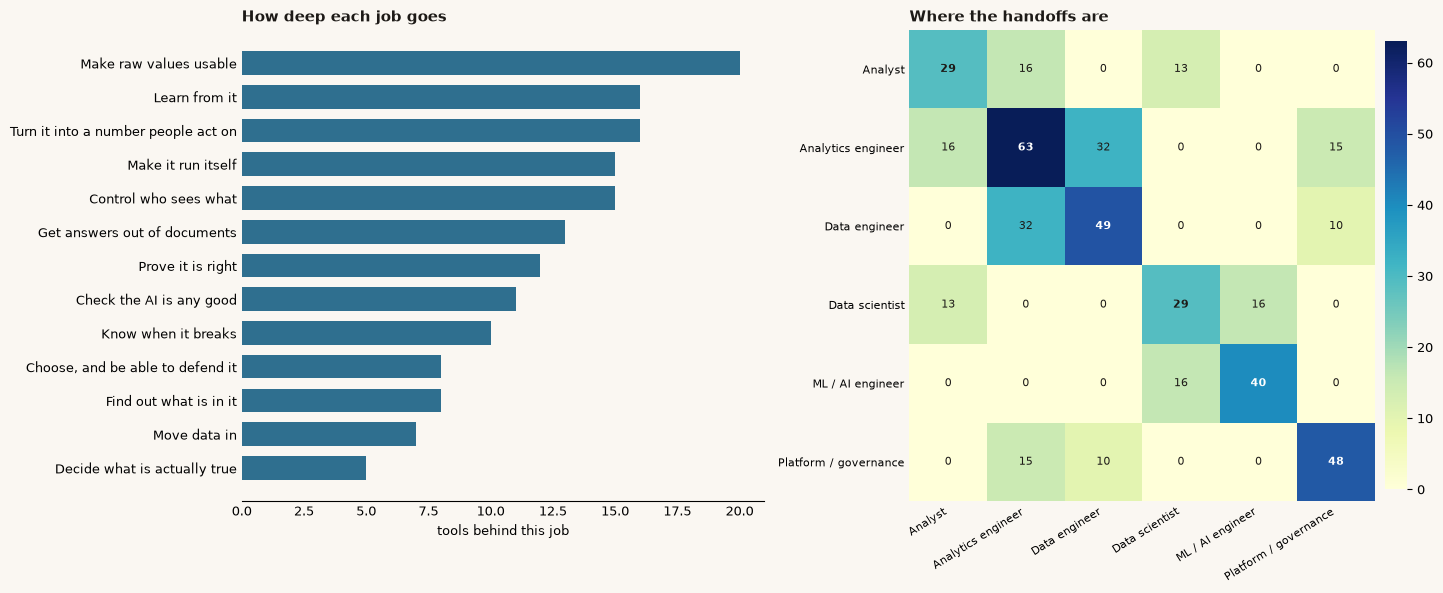

In [5]:
import matplotlib.pyplot as plt
import numpy as np

INK, GRIDC, PAPER, COOL = "#1d1a17", "#e3ddd5", "#faf7f2", "#2f6f8f"
plt.rcParams.update({"figure.facecolor": PAPER, "axes.facecolor": PAPER,
                     "text.color": INK, "font.size": 9})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 6),
                               gridspec_kw={"width_ratios": [1.05, 1]})

order = sorted(TASK_ORDER, key=lambda t: len(grouped[t]))
y = np.arange(len(order))
ax1.barh(y, [len(grouped[t]) for t in order], color=COOL, height=0.7)
ax1.set_yticks(y)
ax1.set_yticklabels([TITLES.get(t, t) for t in order])
ax1.set_xlabel("tools behind this job")
ax1.set_title("How deep each job goes", loc="left", fontweight="bold")
for s in ("top", "right", "left"):
    ax1.spines[s].set_visible(False)
ax1.tick_params(length=0)

grid = np.array([[len(sets[a] & sets[b]) if a != b else len(sets[a])
                  for b in names] for a in names], dtype=float)
im = ax2.imshow(grid, cmap="YlGnBu", aspect="auto")
for i in range(len(names)):
    for j in range(len(names)):
        v = int(grid[i, j])
        ax2.text(j, i, str(v), ha="center", va="center", fontsize=8,
                 color="white" if v > grid.max() * 0.55 else INK,
                 fontweight="bold" if i == j else "normal")
ax2.set_xticks(range(len(names)))
ax2.set_yticks(range(len(names)))
ax2.set_xticklabels(names, rotation=32, ha="right", fontsize=8)
ax2.set_yticklabels(names, fontsize=8)
ax2.set_title("Where the handoffs are", loc="left", fontweight="bold")
for s in ("top", "right", "left", "bottom"):
    ax2.spines[s].set_visible(False)
ax2.tick_params(length=0)
plt.colorbar(im, ax=ax2, fraction=0.045, pad=0.02).outline.set_visible(False)

fig.tight_layout()
fig.savefig("notebook_capability.png", dpi=140, facecolor=PAPER)
plt.show()

## Try your own

Search on the **symptom**, not the technology. The catalog is indexed by what was
going wrong.

In [6]:
def haystack(t: dict) -> str:
    """Hyphens opened up, so a two-word query can hit a slug."""
    return " ".join((t["problem"], t["name"], t["slug"],
                     t["slug"].replace("-", " "), t["task_title"])).lower()


def search(q: str) -> List[dict]:
    """Every token must appear, so a longer query narrows instead of failing."""
    tokens = q.lower().split()
    if not tokens:
        return list(TOOLS)
    return [t for t in TOOLS if all(tok in haystack(t) for tok in tokens)]


for q in ("stale", "line ending", "collation", "cost", "CRLF"):
    hits = search(q)
    jobs = sorted({t["task_title"] for t in hits})
    print(f"\n{q!r} -> {len(hits)} tools across {len(jobs)} jobs")
    for t in hits[:4]:
        print(f"    [{t['task_title']}] {t['name'][:52]}")
    if not hits:
        print("    nothing. Matching is plain substring over the problem text, the name,")
        print("    the slug and the job - no stemming - so a miss is a real gap in what the")
        print("    catalog SAYS, not a scoring artefact. 'CRLF' is a case in point: the tool")
        print("    exists (try 'line ending') and its own description never uses the word.")

# MY_SYMPTOM = "the join tripled the revenue"
# for t in search(MY_SYMPTOM):
#     print(f"[{t['task_title']}] {t['name']}\n    {t['problem']}\n")


'stale' -> 5 tools across 3 jobs
    [Know when it breaks] Data Freshness Monitor
    [Know when it breaks] Data Pipeline Monitor Agent
    [Choose, and be able to defend it] Product Roadmap Visualizer
    [Know when it breaks] Pipeline SLA Monitor

'line ending' -> 1 tools across 1 jobs
    [Make raw values usable] A File Has No Lines In It, a Splitter Makes Them

'collation' -> 1 tools across 1 jobs
    [Make raw values usable] ORDER BY Name Is a Collation, Not an Order

'cost' -> 5 tools across 4 jobs
    [Make raw values usable] Duplicate File Finder
    [Control who sees what] Privacy Policy Generator
    [Check the AI is any good] LLM Cost & Token Tracker
    [Check the AI is any good] Token & Cost Estimator

'CRLF' -> 0 tools across 0 jobs
    nothing. Matching is plain substring over the problem text, the name,
    the slug and the job - no stemming - so a miss is a real gap in what the
    catalog SAYS, not a scoring artefact. 'CRLF' is a case in point: the tool
    exists (t

## What changed here

This tool used to be a **portfolio dashboard**: builds shipped, builds per calendar
day, busiest day, a burn-up against a one-a-day pace line, capped at day 60. It
measured completion of a task list, which is not a question anybody outside the
project has - and it had gone stale at 60 while the catalog passed 150.

It now answers what the catalog covers. Two structural changes came with that:

* **It reads the generated catalog, not the tracker.** It used to run its own
  regex over `TRACKER.md` alongside `build_site.py` - two parsers over one file,
  which disagree eventually. `tracker_parser.py` is now a tombstone pointing here.
* **It gained tests.** The taxonomy is a contract now: if a job is renamed or
  added upstream, `test_capability.py` fails rather than a tab rendering empty.

---

**Interactive:** `streamlit run app.py` - search by symptom, then browse by job,
role or situation.

Part of [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder).